# Comparison of Results Between Models
In comparing performance results between models, we accomplish the following: 

1. Load .csv file for each variable
2. Check for encoding errors
3. For each csv variable, create pd.Dataframe (rows=metrics, columns=models)
4. Using dataframe from previous step, create Matplotlib (grouped bar chart displaying performances of each model on each metric)
5. Interpretations of results
6. Ranking for each model (1st - model name, 2nd - model name, …. 4th- model name).

In [28]:
# import necessary libraries
import joblib
import pandas as pd
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    roc_auc_score, precision_recall_curve, auc, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

lg_csv = pd.read_csv('model_outputs/lg_test_predictions.csv')
rf_csv = pd.read_csv('model_outputs/rf_test_predictions.csv')
gb_csv = pd.read_csv('model_outputs/gb_test_predictions.csv')
mlp_csv = pd.read_csv('model_outputs/mlp_test_predictions.csv')

Check if there errors in the encoding of results. The predicted probability for each csv file must be the probability that it is urban (1). If a predicted probability value is >=0.5, then the corresponding value in predicted class value must be 1 except for logistic regression, which has its own threshold.

In [29]:
def error_check(predictedClass_col, predictedProb_col, threshold=0.5):
    ctr = 0
    for a, b in zip(predictedClass_col, predictedProb_col):
        if b >= threshold:
            if a==0:
                ctr += 1
        else:
            if a==1:
                ctr += 1
    return ctr

lg_threshold = joblib.load('model_outputs/logistic_regression_threshold.pkl')

print("Error Check Count")
print(f"  Logistic Regression    = {error_check(lg_csv["LG_Predicted_Class"], lg_csv["LG_Predicted_Probability"], lg_threshold)}")
print(f"  Random Forest          = {error_check(rf_csv["RF_Predicted_Class"], rf_csv["RF_Predicted_Probability"])}")
print(f"  Gradient Boosting      = {error_check(gb_csv["GB_Predicted_Class"], gb_csv["GB_Predicted_Probability"])}")
print(f"  Multi-Layer Perceptron = {error_check(mlp_csv["MLP_Predicted_Class"], mlp_csv["MLP_Predicted_Probability"])}")

Error Check Count
  Logistic Regression    = 0
  Random Forest          = 0
  Gradient Boosting      = 0
  Multi-Layer Perceptron = 0


Creating Pandas Series to get evaluation metrics for each model and then appending them together to create a dataframe

In [30]:
def model_eval(model_name, y_actual, y_pred, y_prob):
    bal_acc = balanced_accuracy_score(y_actual, y_pred)
    acc = accuracy_score(y_actual, y_pred)
    report = classification_report(y_actual, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_actual, y_prob)
    precision_vals, recall_vals, _ = precision_recall_curve(y_actual, y_prob)
    pr_auc = auc(recall_vals, precision_vals)

    data_index = {
        'Balanced Accuracy': round(bal_acc, 4),
        'Accuracy': round(acc, 4), 
        'Precision (Rural)': round(report['0']['precision'], 4), 
        'Precision (Urban)': round(report['1']['precision'], 4),
        'Recall (Rural)': round(report['0']['recall'], 4), 
        'Recall (Urban)': round(report['1']['recall'], 4), 
        'F1-score (Rural)': round(report['0']['f1-score'], 4), 
        'F1_score (Urban)': round(report['1']['f1-score'], 4),
        'ROC-AUC': round(roc_auc, 4),
        'PR-AUC': round(pr_auc, 4)
    }
    return pd.DataFrame.from_dict(data_index, orient='index', columns=[model_name])


lg_sr = model_eval("Logistic Regression", lg_csv["Actual_y_test"], lg_csv["LG_Predicted_Class"], lg_csv["LG_Predicted_Probability"])
rf_sr = model_eval("Random Forest", rf_csv["Actual_y_test"], rf_csv["RF_Predicted_Class"], rf_csv["RF_Predicted_Probability"])
gb_sr = model_eval("Gradient Boosting", gb_csv["Actual_y_test"], gb_csv["GB_Predicted_Class"], gb_csv["GB_Predicted_Probability"])
mlp_sr = model_eval("Multi-Layer Perceptron", mlp_csv["Actual_y_test"], mlp_csv["MLP_Predicted_Class"], mlp_csv["MLP_Predicted_Probability"])

model_df = pd.concat([lg_sr, rf_sr, gb_sr, mlp_sr], axis=1)
model_df

,Logistic Regression,Random Forest,Gradient Boosting,Multi-Layer Perceptron
Balanced Accuracy,0.7950,0.7899,0.7994,0.7958
Accuracy,0.7995,0.8183,0.8223,0.8161
Precision (Rural),0.8542,0.8162,0.8292,0.8303
Precision (Urban),0.7214,0.8229,0.8083,0.7891
Recall (Rural),0.8142,0.9108,0.8968,0.8825
Recall (Urban),0.7758,0.6691,0.7021,0.7090
F1-score (Rural),0.8337,0.8609,0.8617,0.8556
F1_score (Urban),0.7476,0.7381,0.7515,0.7469
ROC-AUC,0.8833,0.8849,0.8967,0.8903
PR-AUC,0.8537,0.8562,0.8670,0.8618


The table above summarizes the test-set performance of four classifiers trained to predict  whether a household is **Rural (0)** or **Urban (1)**. The dataset is class-imbalanced since rural households outnumber urban. **Balanced Accuracy** is the primary metric for comparing overall model quality, since it accounts for this imbalance by averaging per-class recall.

The metrics cover three dimensions:
- **Discrimination quality** — how well the model separates the two classes (ROC-AUC, PR-AUC)
- **Decision quality** — how useful the model's final binary predictions are (Accuracy, Balanced Accuracy, Precision, Recall, F1-score)
- **Calibration quality** — how reliable the predicted probabilities are (Log Loss)

Per-class metrics are reported separately for Rural and Urban because the cost and difficulty of correctly identifying each class differs. Misclassifying an urban household  as rural (False Negative for Urban) is the harder problem, as urban households are the minority class.

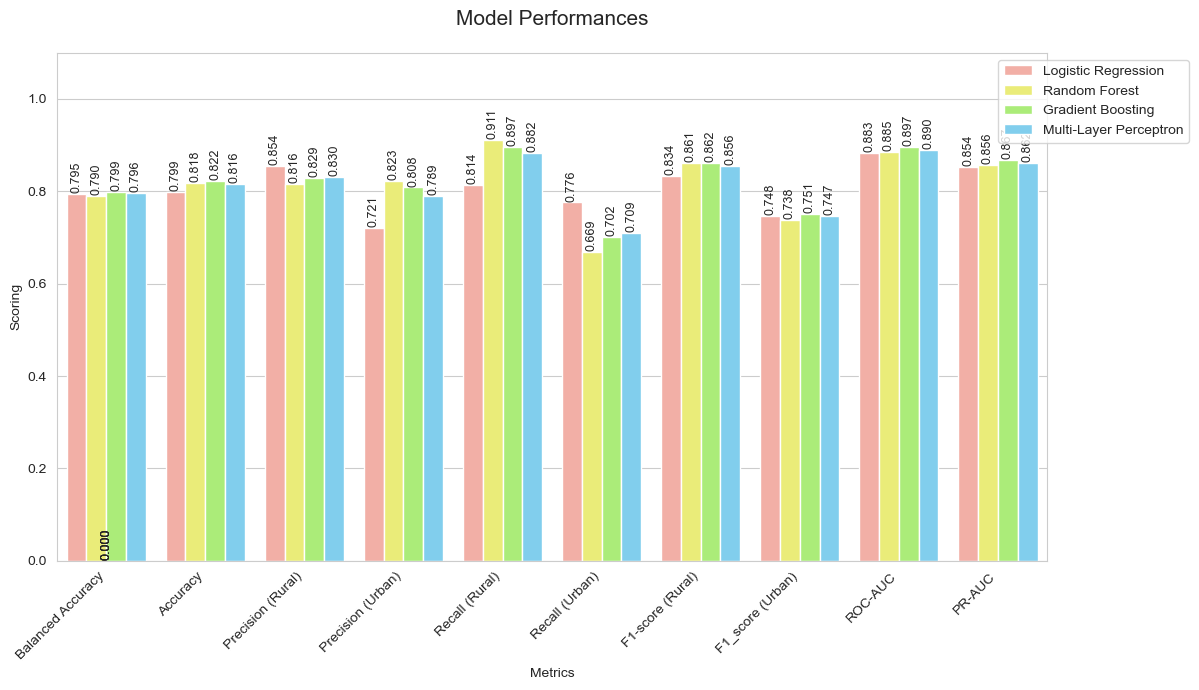

In [31]:

plot_data = model_df
plot_data = plot_data.reset_index().melt(id_vars='index', var_name='Model Stage', value_name='Score')
plot_data.columns = ['Metric', 'Model Stage', 'Score']

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
    
ax = sns.barplot(data=plot_data, x='Metric', y='Score', hue='Model Stage', palette=["#ffa599","#fcff66", "#a8ff66", "#6fd6ff"])
    
plt.title("Model Performances", fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1) # Scores are between 0 and 1
plt.ylabel("Scoring")
plt.xlabel("Metrics")
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 12), 
                textcoords = 'offset points',
                fontsize=9, rotation=90)
plt.tight_layout()
plt.show()

The grouped bar chart above makes the per-metric standings easier to see. Using this bar chart, several patterns can be seen.

**Gradient Boosting consistently occupies the tallest bar** across most metric groups, particularly on Balanced Accuracy, ROC-AUC, PR-AUC, and Urban F1-score. This reflects a model that is better calibrated to the class imbalance and more discriminating overall.

**Random Forest achieves the highest standard Accuracy** and the highest Rural Recall, meaning it correctly identifies the most rural households, however its Urban Recall drops to the lowest among all four models. Thus, Random Forest leans heavily toward predicting Rural, which inflates raw accuracy given that rural is the majority class, but leaves urban households under-detected.

**Logistic Regression leads on Precision (Rural) and Urban Recall**,  meaning that when it predicts a household is rural, it is most often right, and it catches  the most urban households relative to its peers. Its overall metrics are competitive  despite being the simplest model, which suggests the features have a reasonably linear  relationship with the target.

**Multi-Layer Perceptron (MLP) sits in the middle** across nearly all metrics, as it does not lead in any single category but avoids being the worst in any either. This  suggests the neural network is not finding structure that the tree-based models are not,  which may indicate the dataset does not have the complexity or volume needed to give  deep learning a decisive advantage here.

In [32]:
# Comparing of metrics
ctr_lr = 0
ctr_rf = 0
ctr_gb = 0
ctr_mlp = 0

for m1,m2,m3,m4 in zip(lg_sr.iloc[:, 0], rf_sr.iloc[:, 0], gb_sr.iloc[:, 0], mlp_sr.iloc[:, 0]):
    highest_value = max(m1, m2, m3, m4)
    if highest_value==m1:
        ctr_lr += 1
    elif highest_value==m2:
        ctr_rf += 1
    elif highest_value==m3:
        ctr_gb += 1
    elif highest_value==m4:
        ctr_mlp += 1

data_index = {
    'LogisticRegression': ctr_lr,
    'RandomForest': ctr_rf,
    'GradientBoosting': ctr_gb,
    'MultiLayerPerceptron': ctr_mlp
}

ranking_df = pd.DataFrame.from_dict(data_index, orient='index', columns=['Count'])
ranking_df = ranking_df.sort_values(by='Count', ascending=False)
ranking_df

,Count
GradientBoosting,6
LogisticRegression,2
RandomForest,2
MultiLayerPerceptron,0


## Tradeoff Analysis

The ranking table counts, for each metric, which model achieved the highest score.  Gradient Boosting wins 6 out of 10 metrics, making it the strongest overall performer. Logistic Regression and Random Forest each win 2, and MLP wins none.

The table below summarizes the key tradeoffs each model makes:

| Model | Strengths | Weaknesses |
|---|---|---|
| **Gradient Boosting** | Best Balanced Acc, ROC-AUC, PR-AUC, Urban F1 | Moderate Urban Recall |
| **Logistic Regression** | Best Rural Precision, Urban Recall; interpretable | Lowest standard Accuracy |
| **Random Forest** | Highest standard Accuracy, Rural Recall | Lowest Urban Recall ; biased toward Rural |
| **MLP** | Balanced, no catastrophic failures | Wins no metric; highest Log Loss |

Given that the goal is to classify households as rural or urban on an imbalanced dataset, we recommend **Gradient Boosting**. This is because it achieves the best Balanced Accuracy, meaning it performs most fairly across both classes, and has the greatest ROC-AUC and PR-AUC, confirming it produces the most useful probability scores.

**Random Forest should not be chosen** despite its high standard Accuracy, because its loweer Urban Recall 0.669 means it misses roughly 1 in 3 urban households which can be a significant failure given that classification is the primary objective.

**Logistic Regression is the most interpretable** model and performs surprisingly competitively. If model explainability or deployment simplicity is a priority, it remains a viable choice with only a modest performance gap behind Gradient Boosting.

**MLP offers no advantage** in this scenario. Its performance is comparable to Logistic Regression on most metrics but comes with greater computational cost and a higher Log Loss, suggesting its probability estimates are the least well-calibrated among the four for the task.

## Discussion

### Gradient Boosting — Best Overall (6/10 metric wins)

Gradient Boosting leads across the most metrics: Balanced Accuracy, standard Accuracy, F1-score Rural, F1-score Urban, ROC-AUC, and PR-AUC.

Gradient Boosting is an ensemble method that trains decision trees sequentially, where each new tree corrects the residual errors of the previous one. This sequential error-correction mechanism allows it to model complex, non-linear feature interactions that a single model cannot capture. Crucially, because each tree is fitted to residuals rather than raw labels, the algorithm is inherently adaptive — it devotes more capacity to difficult examples over time. On structured tabular data with categorical and ordinal features (such as building type, roof material, and utility access used in this dataset), gradient boosting consistently outperforms other model families because such data tends to have the kinds of threshold-based and interaction-based decision boundaries that decision trees split on naturally.

https://arxiv.org/abs/2207.08815  

---

### Random Forest — Highest Rural Recall, Lowest Urban Recall (2/10 metric wins)

Random Forest achieves the highest Recall (Rural) and Precision (Urban) , yet has the lowest Recall (Urban) at 0.6691 — meaning it misses approximately 1 in 3 urban households. Despite this, it records the second-highest standard Accuracy, which is misleading given the class imbalance.

Logistic Regression models the probability of class membership using a weighted combination of features, producing a smooth decision boundary rather than splitting the data into separate regions like tree-based models. In this dataset, the class_weight='balanced' setting was used, which gives more importance to the minority class (Urban) during training. This means the model is penalized more for misclassifying urban households, helping improve urban recall. As a result, Logistic Regression achieves the most balanced performance between Rural and Urban recall among the models, though this comes with a slight decrease in Rural precision compared to models that are not class-weighted.

https://link.springer.com/article/10.1007/s10994-006-6226-1  
https://scikit-learn.org/stable/modules/ensemble.html#random-forests

---

### Logistic Regression — Most Balanced Recall, Most Interpretable (2/10 metric wins)

Logistic Regression leads on Precision (Rural) and Recall (Urban) with the highest urban recall of any model. Its Balanced Accuracy is competitive with MLP and not far behind Gradient Boosting.

Logistic Regression models the log-odds of class membership as a linear combination of features. Unlike tree-based ensembles, it does not partition the feature space into discrete regions; instead, it fits a continuous decision boundary that weighs all features simultaneously. In this dataset, class_weight='balanced' was used, which gives more importance to the minority class during training. This directly improves urban recall because the model is explicitly penalized more for missing urban households. The result is the most even Rural/Urban recall trade-off among all four models, at the cost of lower Rural Precision compared to unweighted models.

Logistic Regression's competitive performance is also conceptually expected for this problem: the features (utilities, building materials, region) likely have a reasonably monotonic relationship with the rural/urban label, which linear models can exploit without needing the complex interactions that ensemble methods learn.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html   

---

### Multi-Layer Perceptron — No Metric Wins (0/10 metric wins)

The MLP achieves a Balanced Accuracy and ROC-AUC but wins no individual metric. It does not lead in precision, recall, or F1 for either class, and its PR-AUC is only second highest.

Neural networks learn representations through gradient descent over many layers, which makes them powerful for high-dimensional unstructured data (images, text, audio) where useful features must be discovered from raw input. However, for tabular data with  pre-engineered features the useful structure is already explicit in the feature matrix. There is no latent representation to learn. In such settings, tree-based methods that natively handle categorical splits and feature interactions tend to outperform neural networks. Furthermore, the MLP's final chosen architecture is very small (`(8, 4)` hidden layers) to prevent overfitting, which limits its representational capacity. In contrast, Gradient Boosting can grow hundreds of trees each targeting specific residuals, giving it far more effective capacity without overfitting risk.

https://arxiv.org/abs/2207.08815  
https://arxiv.org/abs/2106.11959

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA
- Used Google Gemini for evaluating if code implementation is correct in terms of hyperparameter tuning.
- Used Google Gemini to generate code for visual graphs

Tan, Jeremy James Teves
- Uses ChatGPT to clarify proper flow for training loop
- Uses ChatGPT to assist with understanding errors that came up during debugging
- Uses ChatGPT to clarify errors in python syntax for neural network implementation and training
- Uses Google-search which has AI features in finding sources to justify approaches